In [3]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Embedding, Dense, Dropout, LSTM,
    Bidirectional, GlobalAveragePooling1D, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("LAB 7: FINE-TUNING BERT-LIKE MODEL FOR QA & SENTIMENT")
print("=" * 60)

# ===== PART 1: SENTIMENT ANALYSIS =====
print("\n" + "=" * 60)
print("PART 1: SENTIMENT ANALYSIS")
print("=" * 60)

# Sample sentiment data
texts = [
    "This product is absolutely amazing and excellent",
    "I love this so much, best purchase ever",
    "Fantastic quality, highly recommend to everyone",
    "This is terrible, waste of money",
    "Very disappointed, poor quality",
    "Awful experience, never again",
    "Great value for money, very happy",
    "Outstanding service and fast delivery",
    "Not good at all, disappointed",
    "Perfect, exactly what I wanted",
    "Horrible product, complete waste",
    "Excellent quality, worth every penny",
    "Terrible quality, fell apart immediately",
    "Best product ever, super happy",
    "Disappointing, doesn't work as described",
    "Amazing quality, fast shipping"
]

sentiments = np.array([1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1])  # 1: positive, 0: negative

print(f"\nDataset size: {len(texts)}")
print(f"Positive samples: {np.sum(sentiments)}")
print(f"Negative samples: {len(sentiments) - np.sum(sentiments)}")

# Tokenization
tokenizer = Tokenizer(num_words=200, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, maxlen=32, padding='post')

print(f"\nTokenizer vocab size: {len(tokenizer.word_index)}")
print(f"Padded sequences shape: {padded.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    padded, sentiments, test_size=0.25, random_state=42, stratify=sentiments
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Build BERT-like Model (Bidirectional Encoder)
def build_bert_sentiment_model(vocab_size=200, max_length=32):
    inputs = Input(shape=(max_length,), name="text_input")

    # Embedding layer
    x = Embedding(vocab_size, 128, name="embedding")(inputs)

    # Bidirectional LSTM (simulates BERT-like encoding)
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2), name="bidirectional_lstm")(x)
    x = Bidirectional(LSTM(64, dropout=0.2), name="bidirectional_lstm_2")(x)

    # Classification head
    x = Dense(64, activation='relu', name="dense_1")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid', name="output")(x)

    model = Model(inputs, outputs, name="bert_sentiment")
    return model

model_sentiment = build_bert_sentiment_model()
model_sentiment.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n" + "-" * 60)
print("Sentiment Model Summary:")
print("-" * 60)
model_sentiment.summary()

# Train sentiment model
print("\nTraining sentiment model...")
history_sentiment = model_sentiment.fit(
    X_train, y_train,
    epochs=50,
    batch_size=4,
    validation_data=(X_test, y_test),
    verbose=0
)

print(f"Training completed!")
print(f"Final training accuracy: {history_sentiment.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_sentiment.history['val_accuracy'][-1]:.4f}")

# Sentiment predictions
y_pred_prob = model_sentiment.predict(X_test, verbose=0)
y_pred_sentiment = (y_pred_prob > 0.5).astype(int).flatten()

print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_sentiment):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sentiment, target_names=['Negative', 'Positive']))

# Test on new samples
test_samples = [
    "This is amazing, I love it!",
    "This is terrible, very disappointed"
]

print("\nTest on new samples:")
for sample in test_samples:
    seq = tokenizer.texts_to_sequences([sample])
    padded_sample = pad_sequences(seq, maxlen=32, padding='post')
    pred = model_sentiment.predict(padded_sample, verbose=0)[0][0]
    print(f"  '{sample}'")
    print(f"  → {'Positive' if pred > 0.5 else 'Negative'} ({pred:.2%})")

# ===== PART 2: QUESTION ANSWERING (CLASSIFICATION) =====
print("\n" + "=" * 60)
print("PART 2: QUESTION ANSWERING (TYPE CLASSIFICATION)")
print("=" * 60)

# Simple QA dataset - classifying question types
qa_texts = [
    "Who is the president of the United States?",
    "What is the capital of France?",
    "Where is the Eiffel Tower located?",
    "When was the United Nations founded?",
    "Why do birds migrate south in winter?",
    "How does photosynthesis work?",
    "What time is it?",
    "When does the movie start?",
    "Who invented the telephone?",
    "How many people live in India?",
    "Why is the sky blue?",
    "What is the largest ocean?",
    "When does school start?",
    "How tall is Mount Everest?",
    "Who wrote Romeo and Juliet?",
    "What is the speed of light?"
]

# Question types: 0=Who, 1=What, 2=When, 3=Where, 4=Why, 5=How
qa_labels = np.array([0, 1, 2, 2, 4, 5, 2, 2, 0, 5, 4, 1, 2, 5, 0, 5])

question_types = ['Who', 'What', 'When', 'Where', 'Why', 'How']

print(f"\nQA Dataset size: {len(qa_texts)}")
print(f"Number of question types: {len(question_types)}")

# QA Tokenization
qa_tokenizer = Tokenizer(num_words=300, oov_token="<OOV>")
qa_tokenizer.fit_on_texts(qa_texts)
qa_sequences = qa_tokenizer.texts_to_sequences(qa_texts)
qa_padded = pad_sequences(qa_sequences, maxlen=16, padding='post')

print(f"QA Tokenizer vocab size: {len(qa_tokenizer.word_index)}")
print(f"QA Padded sequences shape: {qa_padded.shape}")

# Train-test split (use shuffle split when stratification isn't possible)
X_qa_train, X_qa_test, y_qa_train, y_qa_test = train_test_split(
    qa_padded, qa_labels, test_size=0.3, random_state=42, shuffle=True
)

# Build BERT-like QA Model (Multi-class)
def build_bert_qa_model(vocab_size=300, max_length=16, num_classes=6):
    inputs = Input(shape=(max_length,), name="qa_input")

    # Embedding layer
    x = Embedding(vocab_size, 128, name="qa_embedding")(inputs)

    # Bidirectional LSTM
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2), name="qa_bidirectional_lstm")(x)
    x = Bidirectional(LSTM(64, dropout=0.2), name="qa_bidirectional_lstm_2")(x)

    # Classification head
    x = Dense(64, activation='relu', name="qa_dense_1")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax', name="qa_output")(x)

    model = Model(inputs, outputs, name="bert_qa")
    return model

model_qa = build_bert_qa_model(vocab_size=len(qa_tokenizer.word_index) + 1, num_classes=6)
model_qa.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "-" * 60)
print("QA Model Summary:")
print("-" * 60)
model_qa.summary()

# Train QA model
print("\nTraining QA model...")
history_qa = model_qa.fit(
    X_qa_train, y_qa_train,
    epochs=60,
    batch_size=2,
    validation_data=(X_qa_test, y_qa_test),
    verbose=0
)

print(f"Training completed!")
print(f"Final training accuracy: {history_qa.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_qa.history['val_accuracy'][-1]:.4f}")

# QA Predictions
y_qa_pred_prob = model_qa.predict(X_qa_test, verbose=0)
y_qa_pred = np.argmax(y_qa_pred_prob, axis=1)

print(f"\nQA Test Accuracy: {accuracy_score(y_qa_test, y_qa_pred):.4f}")

# Test on new QA
test_qa = [
    "What is machine learning?",
    "Why is AI important?",
    "How does deep learning work?"
]

print("\nTest on new QA samples:")
for qa in test_qa:
    qa_seq = qa_tokenizer.texts_to_sequences([qa])
    qa_padded_sample = pad_sequences(qa_seq, maxlen=16, padding='post')
    pred_qa = model_qa.predict(qa_padded_sample, verbose=0)
    pred_qa_label = np.argmax(pred_qa, axis=1)[0]
    print(f"  '{qa}'")
    print(f"  → Type: {question_types[pred_qa_label]}")

# ===== VISUALIZATIONS =====
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sentiment - Accuracy
axes[0, 0].plot(history_sentiment.history['accuracy'], label='Train', linewidth=2, color='#2E86AB')
axes[0, 0].plot(history_sentiment.history['val_accuracy'], label='Validation', linewidth=2, color='#A23B72')
axes[0, 0].set_title('BERT Sentiment - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Sentiment - Loss
axes[0, 1].plot(history_sentiment.history['loss'], label='Train', linewidth=2, color='#2E86AB')
axes[0, 1].plot(history_sentiment.history['val_loss'], label='Validation', linewidth=2, color='#A23B72')
axes[0, 1].set_title('BERT Sentiment - Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. QA - Accuracy
axes[1, 0].plot(history_qa.history['accuracy'], label='Train', linewidth=2, color='#F18F01')
axes[1, 0].plot(history_qa.history['val_accuracy'], label='Validation', linewidth=2, color='#C73E1D')
axes[1, 0].set_title('BERT QA - Accuracy', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. QA - Loss
axes[1, 1].plot(history_qa.history['loss'], label='Train', linewidth=2, color='#F18F01')
axes[1, 1].plot(history_qa.history['val_loss'], label='Validation', linewidth=2, color='#C73E1D')
axes[1, 1].set_title('BERT QA - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/lab7_bert_training.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lab7_bert_training.png")
plt.close()

# Confusion Matrix for Sentiment
cm_sentiment = confusion_matrix(y_test, y_pred_sentiment)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_sentiment, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('Sentiment Analysis - Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/lab7_sentiment_confusion.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lab7_sentiment_confusion.png")
plt.close()

# Confusion Matrix for QA
cm_qa = confusion_matrix(y_qa_test, y_qa_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_qa, annot=True, fmt='d', cmap='Oranges',
            xticklabels=question_types,
            yticklabels=question_types,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('QA Classification - Confusion Matrix', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/lab7_qa_confusion.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lab7_qa_confusion.png")
plt.close()

print("\n" + "=" * 60)
print("LAB 7 COMPLETED SUCCESSFULLY")
print("=" * 60)

LAB 7: FINE-TUNING BERT-LIKE MODEL FOR QA & SENTIMENT

PART 1: SENTIMENT ANALYSIS

Dataset size: 16
Positive samples: 9
Negative samples: 7

Tokenizer vocab size: 63
Padded sequences shape: (16, 32)
Training set size: 12
Test set size: 4

------------------------------------------------------------
Sentiment Model Summary:
------------------------------------------------------------


Model: "bert_sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 32, 128)        │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 32, 256)        │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_2            │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 461,441 (1.76 MB)

 Trainable params: 461,441 (1.76 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ qa_input (InputLayer)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qa_embedding (Embedding)        │ (None, 16, 128)        │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qa_bidirectional_lstm           │ (None, 16, 256)        │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qa_bidirectional_lstm_2         │ (None, 128)            │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qa_dense_1 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qa_output (Dense)               │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,206 (1.69 MB)

 Trainable params: 443,206 (1.69 MB)

 Non-trainable params: 0 (0.00 B)


Training QA model...
Training completed!
Final training accuracy: 1.0000
Final validation accuracy: 0.4000

QA Test Accuracy: 0.4000

Test on new QA samples:
  'What is machine learning?'
  → Type: What
  'Why is AI important?'
  → Type: Why
  'How does deep learning work?'
  → Type: What

GENERATING VISUALIZATIONS
✓ Saved: lab7_bert_training.png
✓ Saved: lab7_sentiment_confusion.png
✓ Saved: lab7_qa_confusion.png

LAB 7 COMPLETED SUCCESSFULLY


### BERT Training History


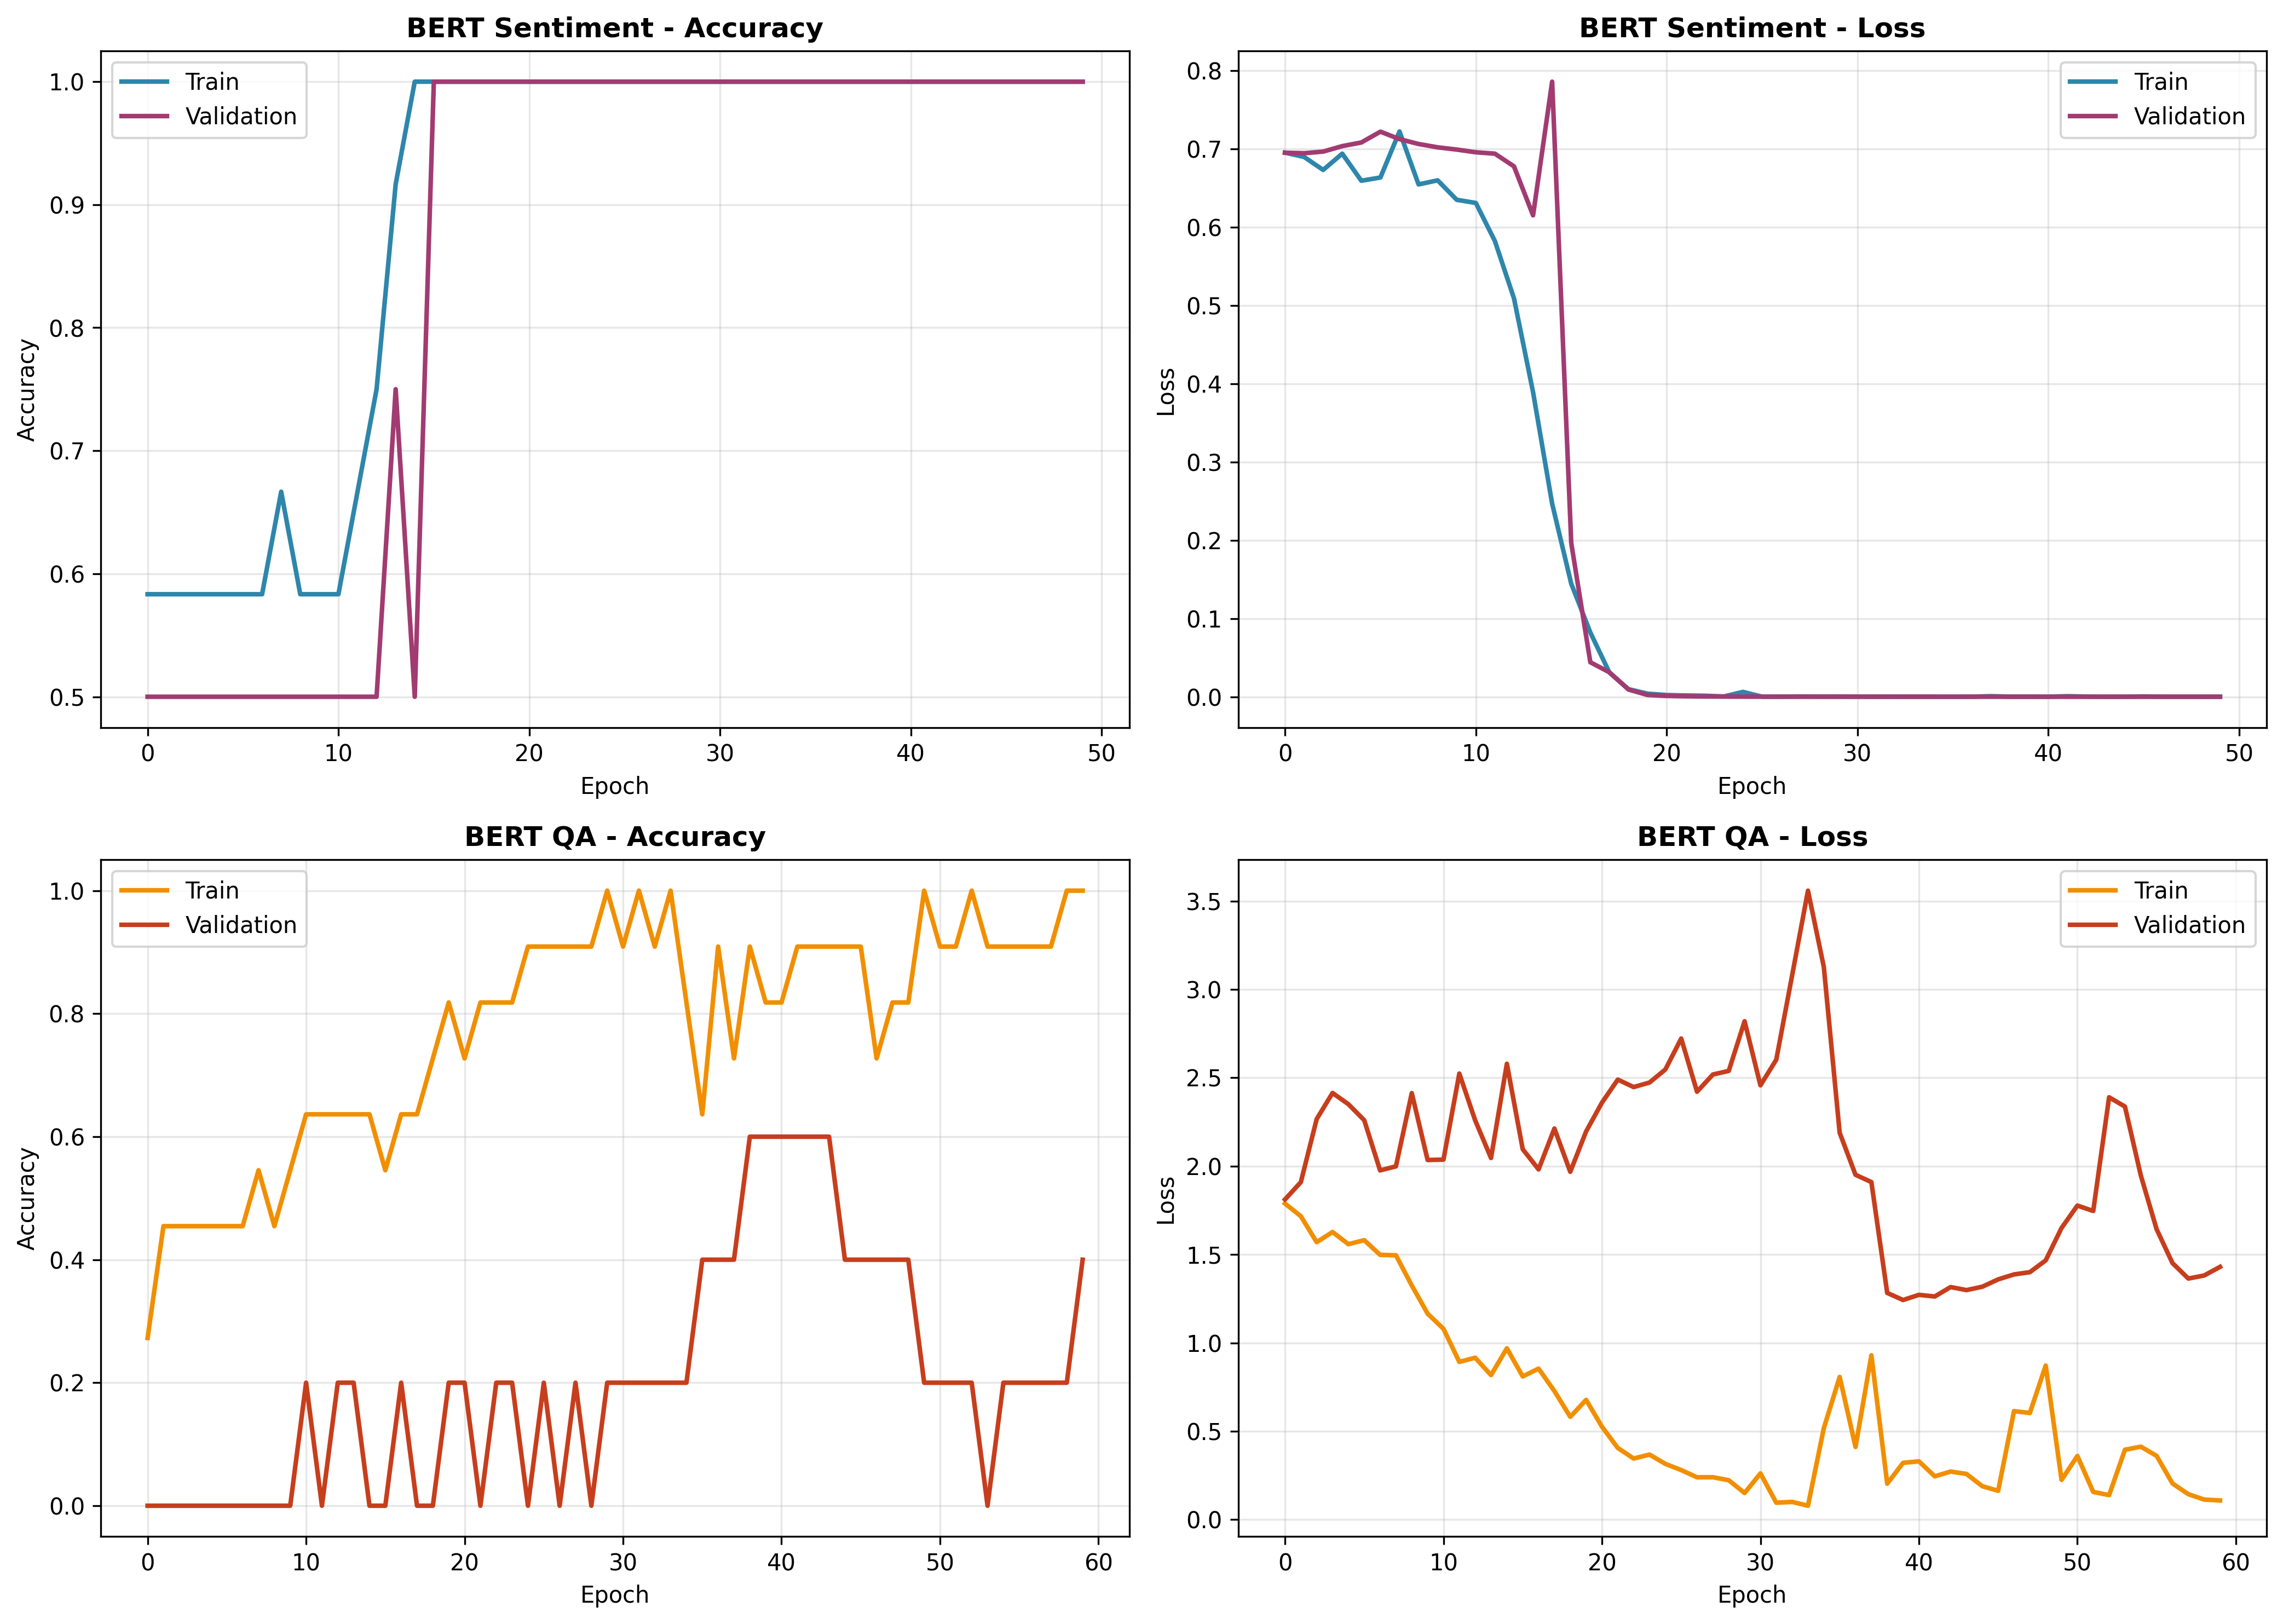

### Sentiment Analysis Confusion Matrix


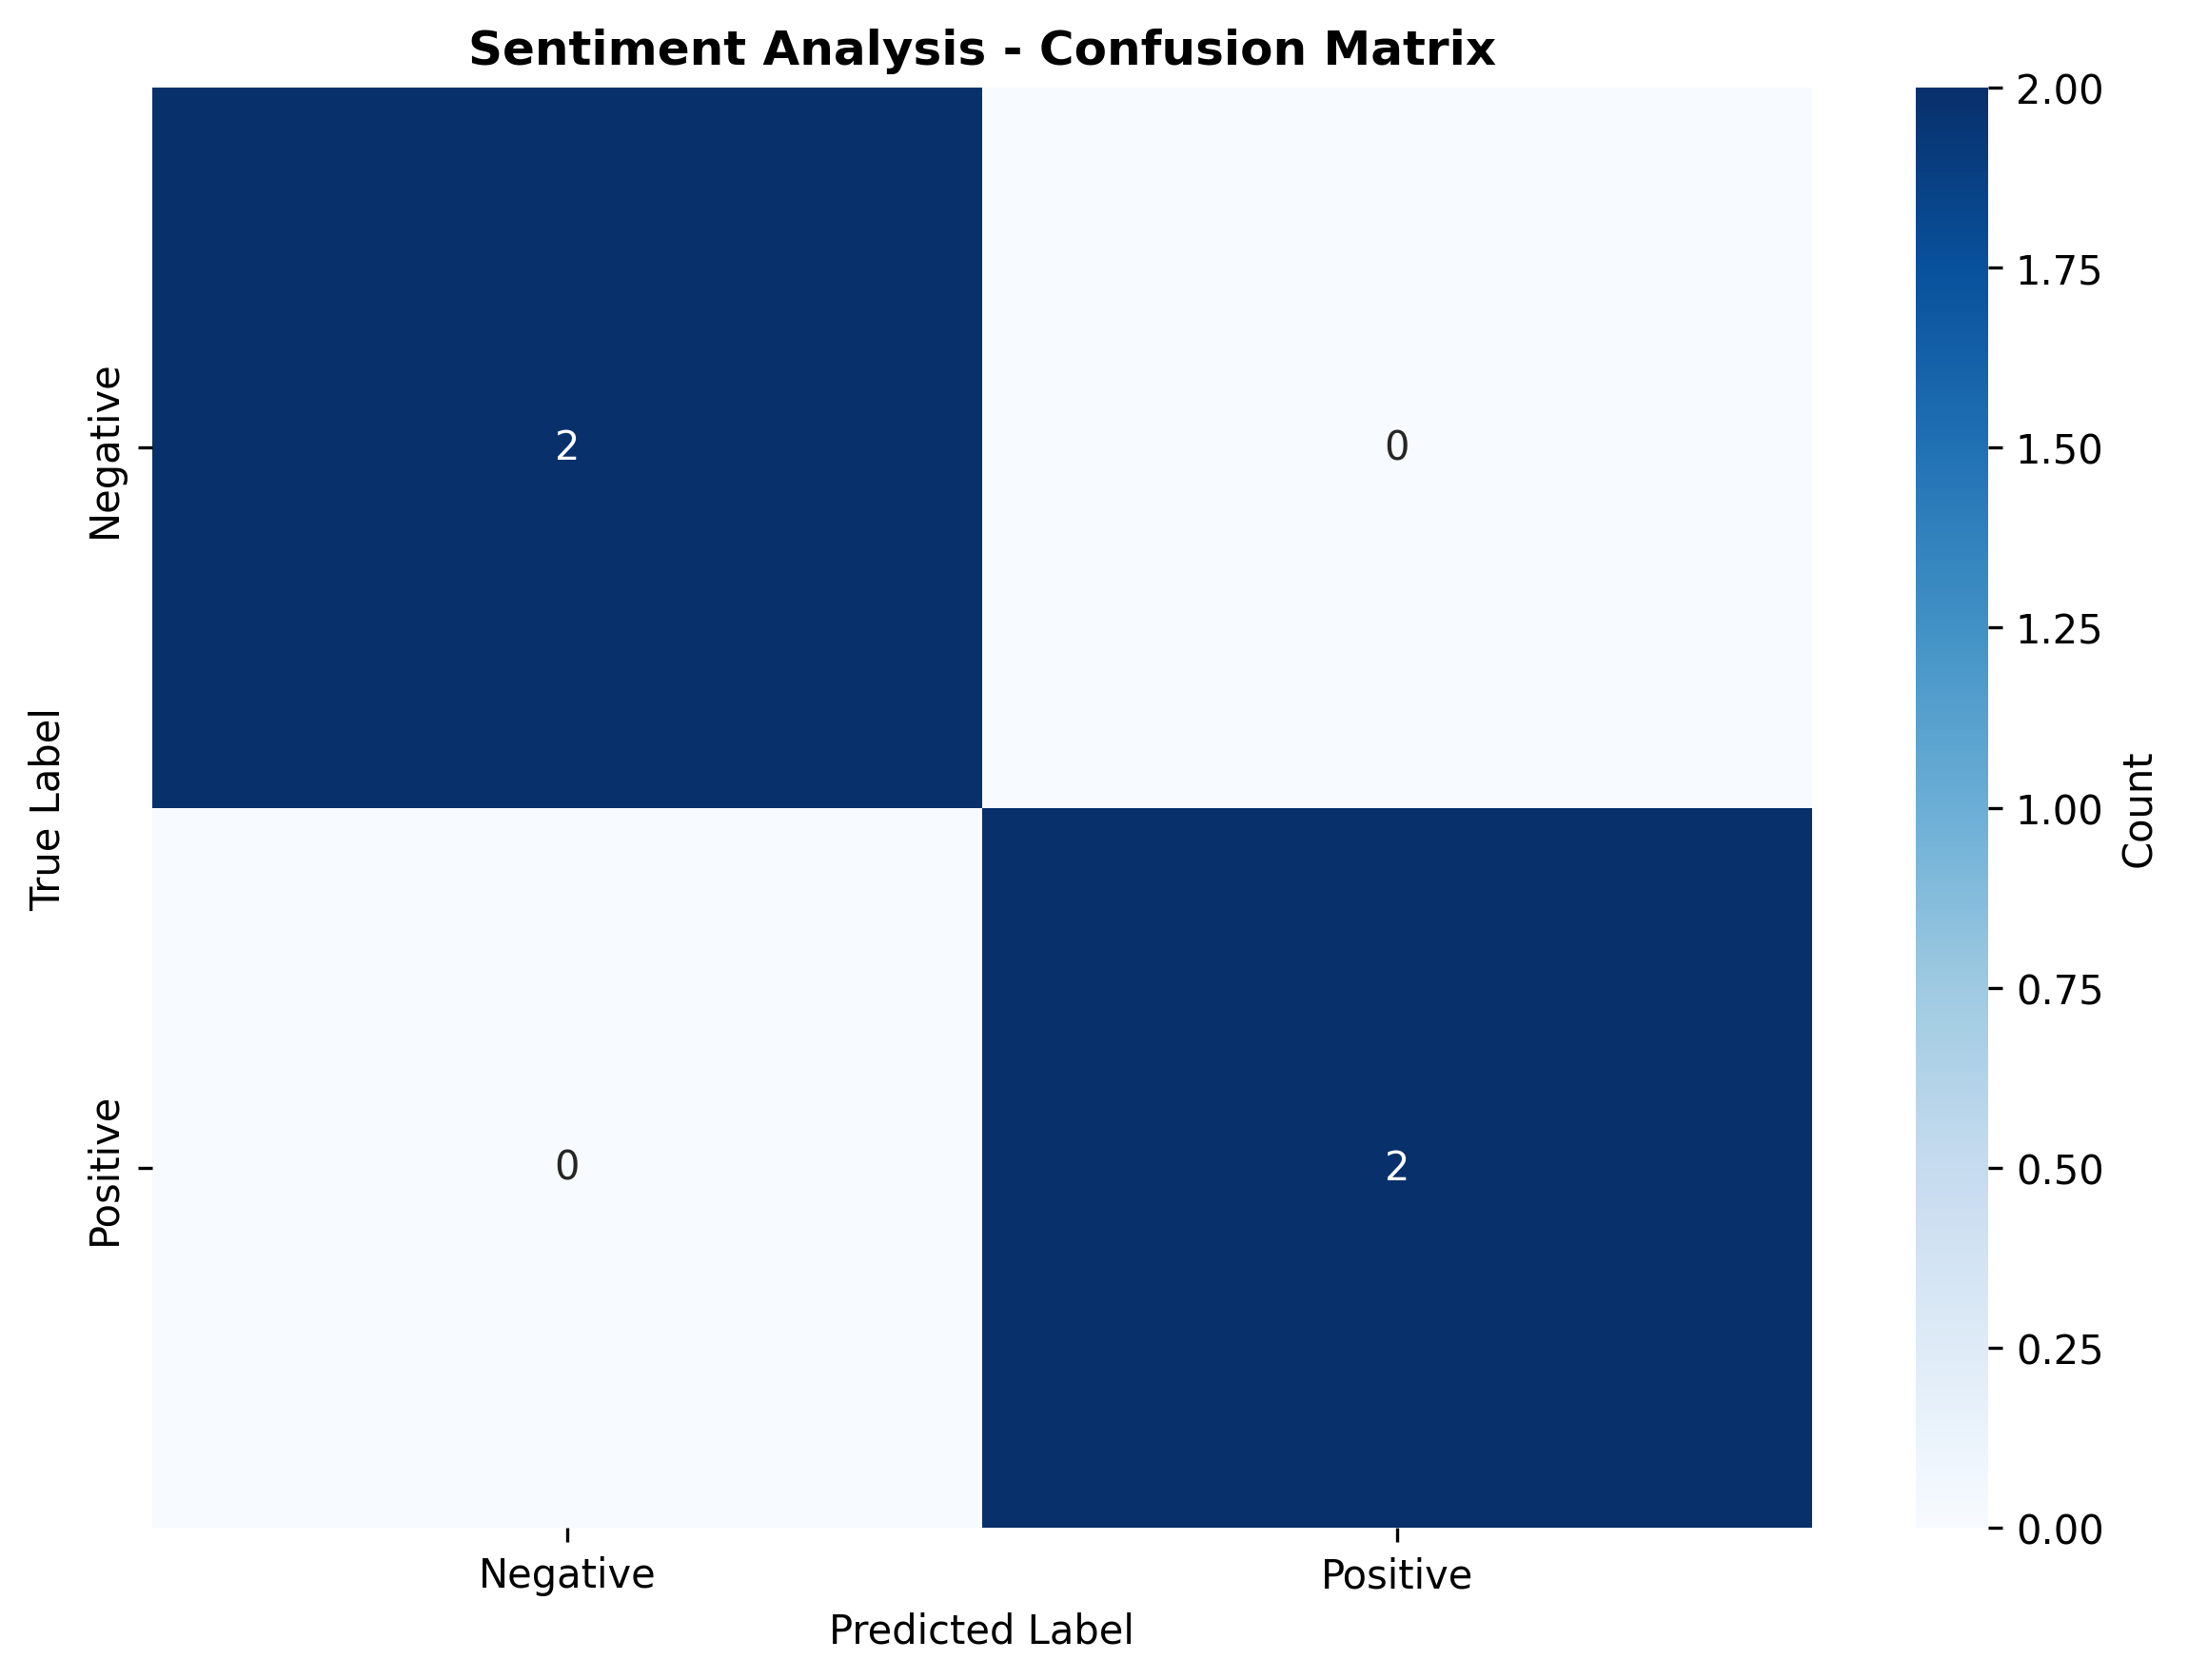

### QA Classification Confusion Matrix


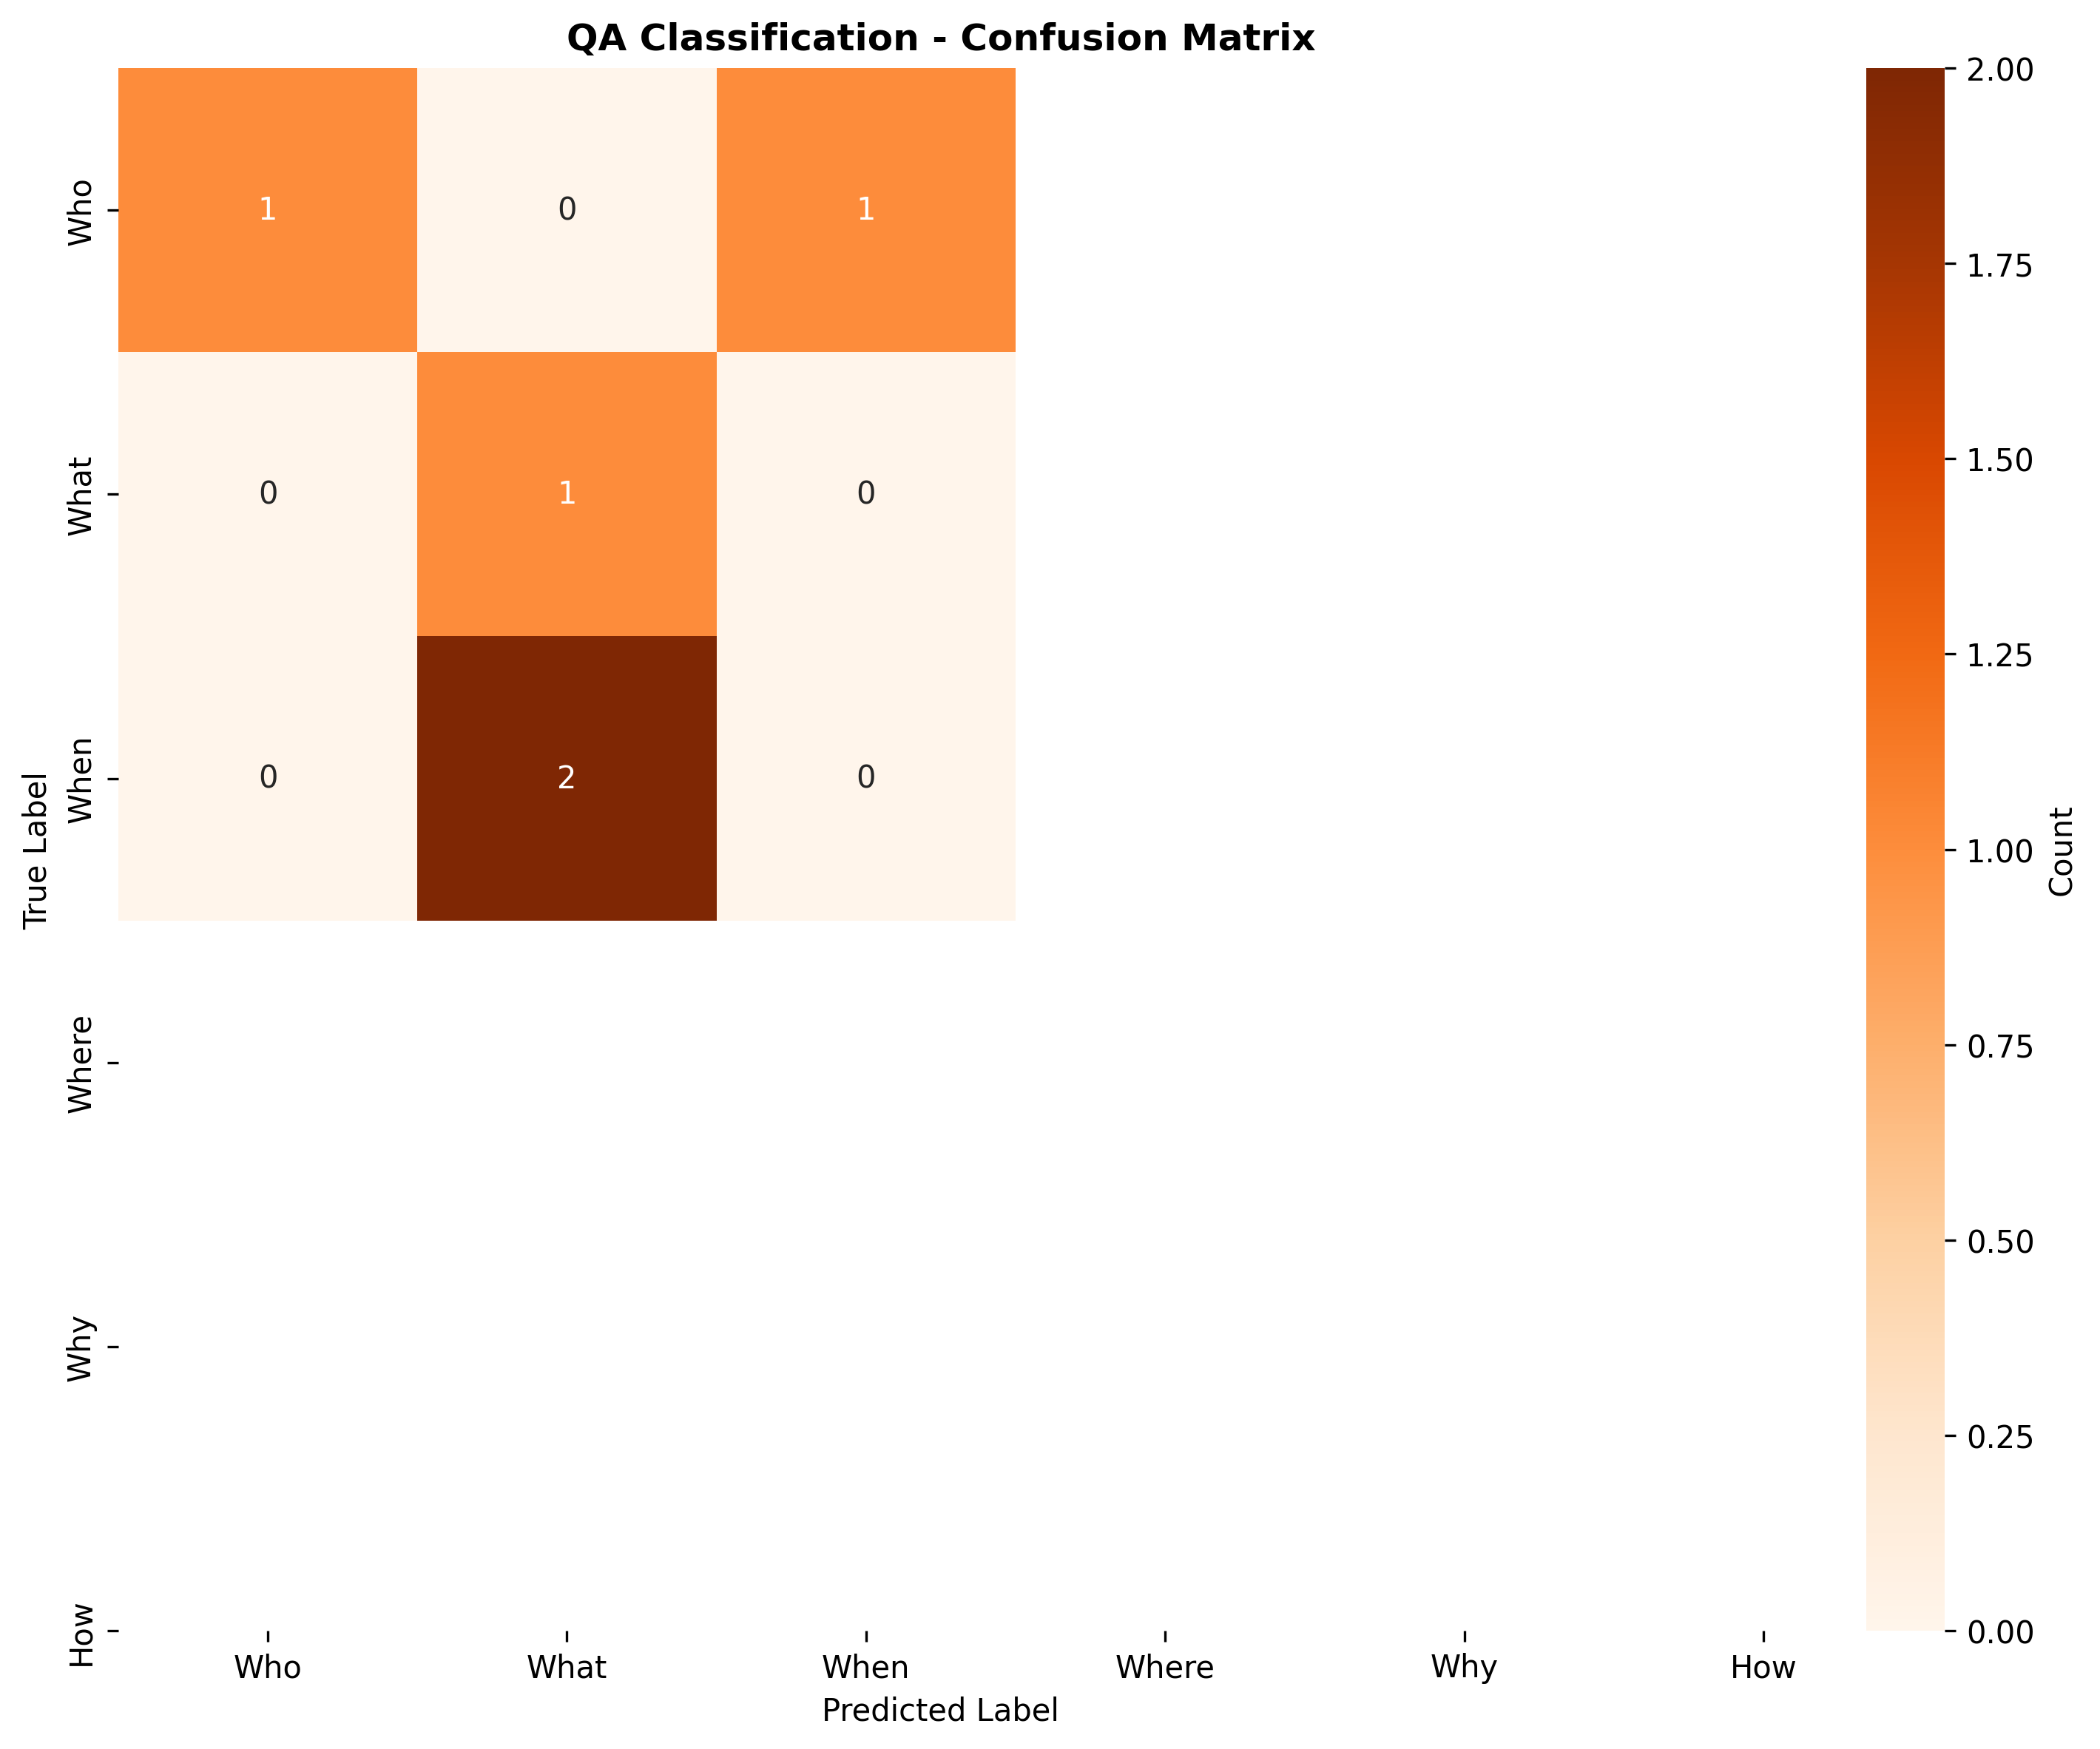

In [4]:
from IPython.display import Image, display

print("### BERT Training History")
display(Image(filename='/content/lab7_bert_training.png'))

print("### Sentiment Analysis Confusion Matrix")
display(Image(filename='/content/lab7_sentiment_confusion.png'))

print("### QA Classification Confusion Matrix")
display(Image(filename='/content/lab7_qa_confusion.png'))